# Customer Churn Prediction & Retention Analytics

## Exploratory Data Analysis

### Business Objective

Identify the key behavioural and customer characteristics associated with churn and uncover opportunities for improving retention.

# Customer Churn Prediction & Retention Analytics

## Exploratory Data Analysis

### Business Objective

This analysis explores customer behaviour, subscription patterns, and support interactions to identify the key factors associated with customer churn. The findings will inform retention strategies and support the development of a predictive churn model.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "/kaggle/input/datasets/neelamsingh1987/customer-churn-dataset"

customer_data = pd.read_csv(f"{DATA_PATH}/customer_churn_final.csv")

In [3]:
import sqlite3

conn = sqlite3.connect(f"{DATA_PATH}/customer_churn_analytics.db")

**Data Overview**

In [4]:
customer_data.shape

(10000, 16)

In [5]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   10000 non-null  int64  
 1   signup_date                   10000 non-null  object 
 2   region                        10000 non-null  object 
 3   age_group                     10000 non-null  object 
 4   subscription_type             10000 non-null  object 
 5   monthly_revenue               10000 non-null  int64  
 6   tenure_months                 10000 non-null  int64  
 7   monthly_login_count           10000 non-null  float64
 8   average_session_time_minutes  10000 non-null  float64
 9   features_used                 10000 non-null  float64
 10  last_login_days_ago           10000 non-null  float64
 11  complaint_count               10000 non-null  float64
 12  response_time_hours           10000 non-null  float64
 13  re

In [6]:
customer_data.isnull().sum()

customer_id                     0
signup_date                     0
region                          0
age_group                       0
subscription_type               0
monthly_revenue                 0
tenure_months                   0
monthly_login_count             0
average_session_time_minutes    0
features_used                   0
last_login_days_ago             0
complaint_count                 0
response_time_hours             0
resolution_time_hours           0
customer_satisfaction_score     0
churn                           0
dtype: int64

In [7]:
customer_data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,15000.50,2886.90,10001.00,12500.75,15000.50,17500.25,20000.00
monthly_revenue,10000.0,73.30,56.21,29.00,29.00,79.00,79.00,199.00
tenure_months,10000.0,41.95,17.46,12.00,27.00,42.00,57.00,73.00
monthly_login_count,10000.0,13.69,4.81,0.00,12.17,14.50,16.67,25.67
average_session_time_minutes,10000.0,25.08,2.84,15.62,23.14,25.04,27.01,35.45
features_used,10000.0,4.66,1.28,1.00,4.25,4.92,5.42,7.58
last_login_days_ago,10000.0,34.72,17.96,12.00,26.42,30.17,34.33,119.00
complaint_count,10000.0,2.97,2.63,0.00,1.00,3.00,5.00,15.00
response_time_hours,10000.0,18.96,14.17,0.00,3.82,20.38,29.81,48.00
resolution_time_hours,10000.0,47.27,35.28,0.00,9.36,49.94,74.44,119.99


In [8]:
customer_data.duplicated().sum()

np.int64(0)

# 2. Overall Churn Analysis

## Business Question

What proportion of customers have cancelled their subscriptions, and what is the overall retention health of the business?

Understanding the current churn rate provides a baseline measurement for evaluating customer retention performance and identifying the scale of the business problem.

In [9]:
# Calculate Churn Rate

churn_rate = customer_data["churn"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 15.04%


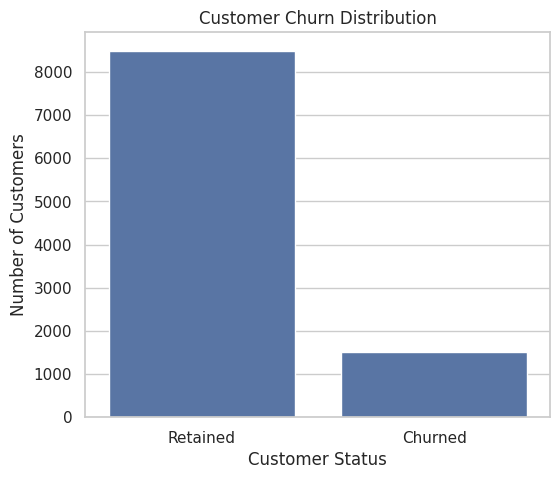

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=customer_data,
    x="churn"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.xticks(
    [0,1],
    ["Retained","Churned"]
)

plt.show()

## Business Insight

The analysis shows that approximately **15% of customers have churned**, while the majority of customers remain active. Although the business retains most customers, the churn rate represents a significant opportunity for improvement due to the impact of lost recurring subscription revenue.

Understanding the behavioural and customer characteristics associated with churn will help identify high-risk customers and develop targeted retention strategies.

## Key Findings

- The dataset contains **10,000 customers**.
- **8,496 customers (84.96%)** remain active.
- **1,504 customers (15.04%)** have churned.
- The churn rate provides a baseline metric for measuring future retention improvements.
- Further analysis will investigate whether subscription type, customer engagement, tenure, and support experience influence churn behaviour.

# 3. Churn by Subscription Type

## Business Question

Does customer churn vary across different subscription plans?

Understanding which subscription tiers experience the highest churn can help the business identify customer segments requiring improved onboarding, engagement, or retention strategies.

In [11]:
# Calculate the percentage of customers who churned within each subscription plan.
# This helps identify which subscription tiers experience the highest customer churn.

subscription_churn = (
    customer_data
    .groupby("subscription_type")["churn"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

subscription_churn

subscription_type
Professional    15.49
Basic           14.74
Enterprise      14.74
Name: churn, dtype: float64

In [12]:
# Convert the results into a structured DataFrame for easier interpretation
# and to prepare the data for visualisation.

subscription_churn_df = (
    subscription_churn
    .reset_index()
)

subscription_churn_df.columns = [
    "Subscription Type",
    "Churn Rate (%)"
]

subscription_churn_df

,Subscription Type,Churn Rate (%)
0,Professional,15.49
1,Basic,14.74
2,Enterprise,14.74


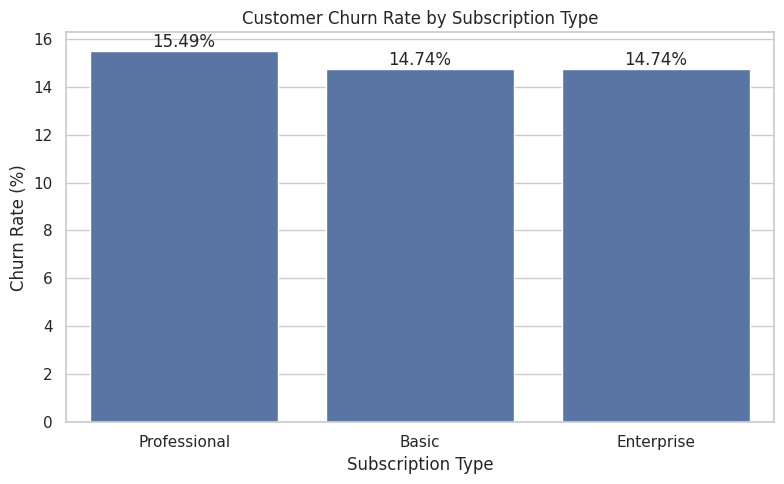

In [13]:
# Create a bar chart to compare churn rates across subscription plans.
# Percentage labels are added above each bar to improve readability.

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=subscription_churn_df,
    x="Subscription Type",
    y="Churn Rate (%)"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Customer Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.show()

## Key Findings

- The **Professional** subscription recorded the highest churn rate at **15.49%**.
- Both **Basic** and **Enterprise** subscriptions recorded churn rates of **14.74%**.
- The difference between subscription plans is relatively small, suggesting that subscription tier is not a major driver of customer churn.
- Additional analysis is required to investigate whether engagement metrics, support interactions, customer satisfaction, or tenure have a stronger relationship with churn.

In [14]:
# Calculate customer churn rates across geographic regions to determine
# whether retention performance varies by market.

region_churn = (
    customer_data
    .groupby("region")["churn"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

region_churn

region
London        16.02
Bristol       15.44
Leeds         15.12
Glasgow       15.10
Manchester    14.61
Birmingham    13.24
Name: churn, dtype: float64

# 4. Churn by Region

## Business Question

Does customer churn vary across different geographic regions?

Analysing churn by region helps identify geographical markets with lower customer retention, enabling the business to target regional retention initiatives and better allocate customer success resources.

In [15]:
# Convert the regional churn results into a DataFrame
# to improve readability and prepare the data for visualisation.

region_churn_df = (
    region_churn
    .reset_index()
)

region_churn_df.columns = [
    "Region",
    "Churn Rate (%)"
]

region_churn_df

,Region,Churn Rate (%)
0,London,16.02
1,Bristol,15.44
2,Leeds,15.12
3,Glasgow,15.10
4,Manchester,14.61
5,Birmingham,13.24


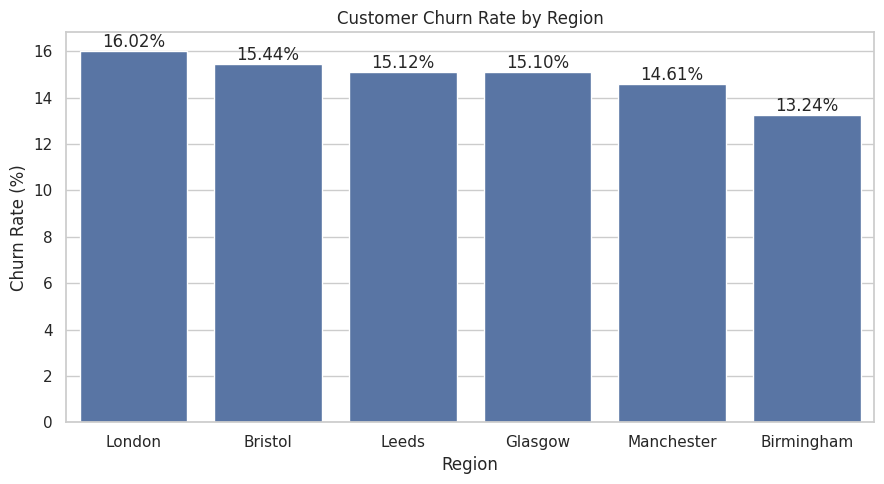

In [16]:
# Create a bar chart to compare customer churn rates across regions.
# Display percentage labels above each bar for easier interpretation.

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=region_churn_df,
    x="Region",
    y="Churn Rate (%)"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Customer Churn Rate by Region")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.show()

## Key Findings

- **London** recorded the highest customer churn rate at **16.02%**.
- **Bristol (15.44%)**, **Leeds (15.12%)**, and **Glasgow (15.10%)** also reported churn rates above the overall average.
- **Birmingham** achieved the lowest churn rate at **13.24%**, indicating comparatively stronger customer retention.
- While regional differences are modest, the results suggest that geography may contribute to customer retention and should be investigated alongside behavioural and support-related factors.

## Business Insight

Customer churn varies moderately across geographic regions, with London recording the highest churn rate (16.02%) and Birmingham the lowest (13.24%). Although the differences are relatively small, they suggest that regional factors such as customer engagement, local market conditions, or differences in customer support may influence retention.

These findings indicate that monitoring customer performance at a regional level could help identify markets that would benefit from targeted customer success initiatives and retention campaigns.

### Conclusion

Regional differences in churn are present but relatively modest. This suggests that while location may influence customer retention, behavioural characteristics such as product usage, customer tenure, and support experience are likely to have a greater impact. The next section explores whether customer tenure is associated with churn.

# 5. Churn by Customer Tenure

## Business Question

Does customer churn vary according to the length of time a customer has been subscribed?

Customer tenure is an important indicator of customer loyalty. Analysing churn across different tenure groups helps determine whether newer or longer-term customers are more likely to cancel their subscriptions.

In [17]:
# Group customers into tenure categories to compare churn rates
# across different stages of the customer lifecycle.

customer_data["tenure_group"] = pd.cut(
    customer_data["tenure_months"],
    bins=[0, 24, 48, 72],
    labels=["1–24 Months", "25–48 Months", "49–72 Months"]
)

customer_data[["tenure_months", "tenure_group"]].head()

,tenure_months,tenure_group
0,35,25–48 Months
1,24,1–24 Months
2,44,25–48 Months
3,29,25–48 Months
4,35,25–48 Months


In [18]:
# Calculate the percentage of customers who churned within each
# customer tenure group.

tenure_churn = (
    customer_data
    .groupby("tenure_group", observed=False)["churn"]
    .mean()
    .mul(100)
    .round(2)
)

tenure_churn

tenure_group
1–24 Months     14.77
25–48 Months    14.78
49–72 Months    15.36
Name: churn, dtype: float64

In [19]:
# Convert the tenure churn results into a DataFrame
# for easier interpretation and visualisation.

tenure_churn_df = (
    tenure_churn
    .reset_index()
)

tenure_churn_df.columns = [
    "Tenure Group",
    "Churn Rate (%)"
]

tenure_churn_df

,Tenure Group,Churn Rate (%)
0,1–24 Months,14.77
1,25–48 Months,14.78
2,49–72 Months,15.36


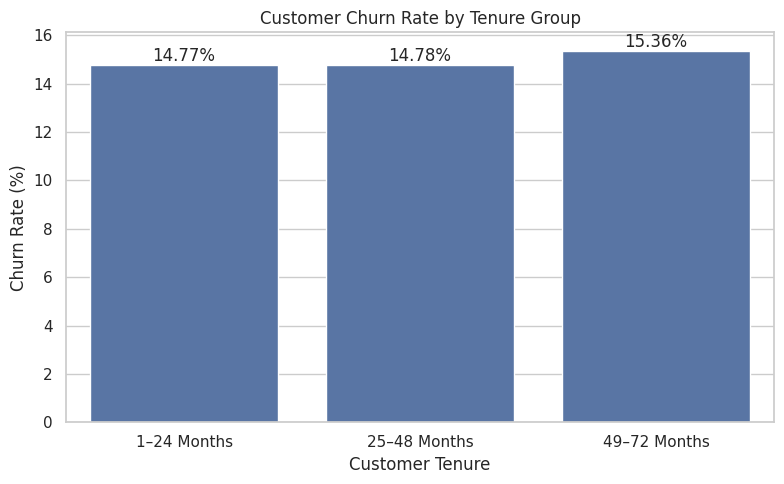

In [20]:
# Create a bar chart comparing churn rates across customer
# tenure groups and display percentage labels.

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=tenure_churn_df,
    x="Tenure Group",
    y="Churn Rate (%)"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.show()

## Key Findings

- Customers with **49–72 months** of tenure recorded the highest churn rate at **15.36%**.
- Customers with **1–24 months** and **25–48 months** of tenure experienced very similar churn rates of **14.77%** and **14.78%**, respectively.
- The small variation across tenure groups suggests that customer longevity is not a strong predictor of churn in this dataset.
- Further analysis should focus on behavioural and support-related variables to identify stronger indicators of customer churn.

## Business Insight

Customer churn remains relatively consistent across all tenure groups, ranging from **14.77%** to **15.36%**. Contrary to the expectation that newer customers are more likely to cancel, the analysis suggests that customer tenure alone has only a limited influence on churn within this dataset.

This finding indicates that other factors, such as customer engagement, product usage, support experience, and customer satisfaction, are likely to play a more significant role in predicting customer churn.

### Conclusion

Customer tenure shows only a weak relationship with churn, suggesting that simply retaining customers for longer does not necessarily reduce the likelihood of cancellation. The next stage of the analysis will investigate the financial impact of customer churn by estimating the recurring revenue lost when customers leave.

# 6. Revenue Impact of Customer Churn

## Business Question

How much recurring monthly revenue is lost due to customer churn?

While the churn rate indicates the proportion of customers who leave, estimating the associated revenue loss helps quantify the financial impact of customer attrition and highlights the importance of effective customer retention strategies.

In [21]:
# Calculate total monthly revenue and revenue lost from churned customers.
# This measures the financial impact of customer churn.

total_monthly_revenue = (
    customer_data["monthly_revenue"]
    .sum()
)

lost_revenue = (
    customer_data
    .loc[customer_data["churn"] == 1, "monthly_revenue"]
    .sum()
)

print(
    f"Total Monthly Revenue: £{total_monthly_revenue:,.2f}"
)

print(
    f"Revenue Lost from Churn: £{lost_revenue:,.2f}"
)

Total Monthly Revenue: £733,000.00
Revenue Lost from Churn: £110,416.00


In [22]:
# Calculate the percentage of revenue lost due to customer churn.
# This shows the financial proportion affected by cancellations.

lost_revenue_pct = (
    lost_revenue / total_monthly_revenue
) * 100


print(
    f"Percentage of Revenue Lost: {lost_revenue_pct:.2f}%"
)

Percentage of Revenue Lost: 15.06%


In [23]:
# Create a summary table showing total revenue and revenue lost from churn.
# This highlights the financial impact of customer cancellations.

revenue_impact_df = pd.DataFrame({
    "Revenue Category": [
        "Retained Revenue",
        "Revenue Lost from Churn"
    ],
    "Monthly Revenue": [
        total_monthly_revenue - lost_revenue,
        lost_revenue
    ]
})

revenue_impact_df

,Revenue Category,Monthly Revenue
0,Retained Revenue,622584
1,Revenue Lost from Churn,110416


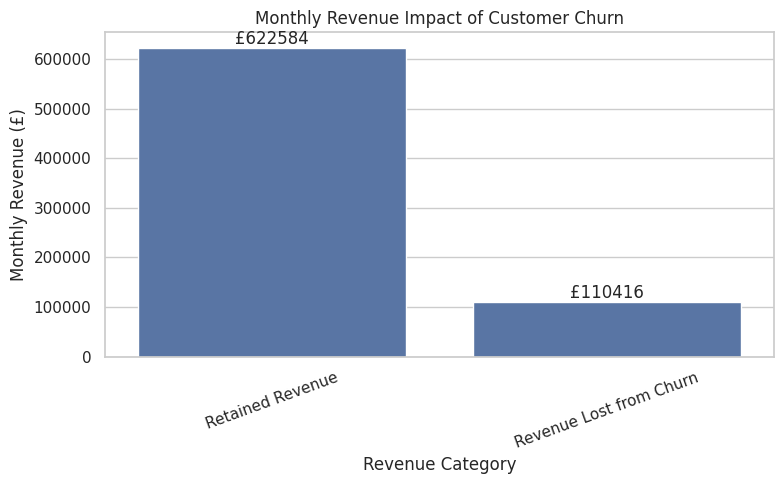

In [24]:
# Visualise retained revenue versus revenue lost from churn.
# This shows the financial opportunity from reducing customer churn.

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=revenue_impact_df,
    x="Revenue Category",
    y="Monthly Revenue"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="£%.0f"
    )

plt.title(
    "Monthly Revenue Impact of Customer Churn"
)

plt.xlabel(
    "Revenue Category"
)

plt.ylabel(
    "Monthly Revenue (£)"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Key Findings

- The business generates **£733,000** in monthly recurring revenue.
- Customers who churn account for approximately **£110,416** in lost monthly revenue.
- Churn represents **15.06%** of the company's monthly recurring revenue.
- Reducing customer churn by even a small percentage could protect a significant amount of recurring revenue and improve long-term business profitability.

## Business Insight

The company generates **£733,000** in monthly recurring revenue (MRR), of which approximately **£110,416 (15.06%)** is lost due to customer churn. This closely aligns with the overall churn rate, indicating that revenue loss is broadly proportional to the number of customers leaving.

These findings demonstrate the significant financial impact of customer attrition and reinforce the importance of identifying high-risk customers before they cancel their subscriptions. Even modest improvements in customer retention could result in substantial recurring revenue gains.

### Conclusion

The financial impact of customer churn extends beyond customer numbers, resulting in the loss of over **£110,000** in recurring monthly revenue. Having quantified the business impact, the next stage of the analysis investigates customer engagement metrics to determine whether differences in platform usage are associated with customer churn.

# 7. Customer Engagement Analysis

## Business Question

Does customer engagement influence the likelihood of customer churn?

Customer engagement is a key indicator of product adoption and customer value. By comparing engagement metrics between retained and churned customers, we can identify behavioural patterns associated with customer attrition and uncover opportunities for proactive retention strategies.

# 7. Customer Engagement Analysis

## Business Question

Does customer engagement influence the likelihood of customer churn?

Understanding differences in product usage between retained and churned customers can help identify behavioural patterns that indicate increased churn risk.

In [25]:
# Calculate the average monthly login count for retained and churned customers.
# This helps determine whether lower platform engagement is associated with churn.

login_analysis = (
    customer_data
    .groupby("churn")["monthly_login_count"]
    .mean()
    .round(2)
)

login_analysis

churn
0    14.98
1     6.40
Name: monthly_login_count, dtype: float64

In [26]:
# Convert the login comparison into a readable table
# showing average monthly logins by customer status.

login_analysis_df = (
    login_analysis
    .reset_index()
)

login_analysis_df.columns = [
    "Customer Status",
    "Average Monthly Logins"
]

login_analysis_df["Customer Status"] = (
    login_analysis_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

login_analysis_df

,Customer Status,Average Monthly Logins
0,Retained,14.98
1,Churned,6.40


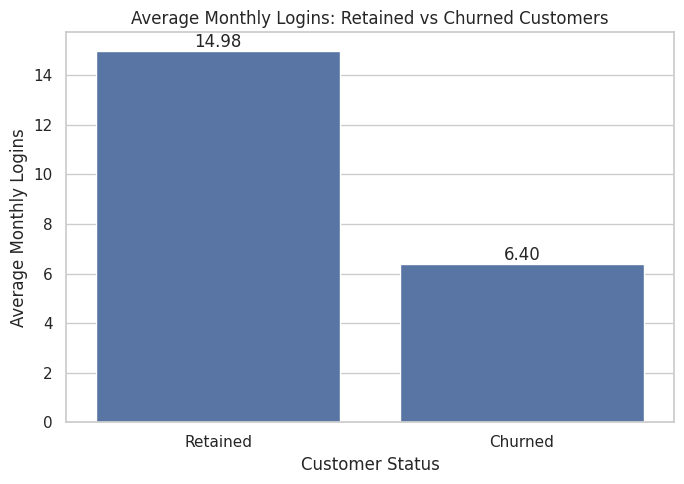

In [27]:
# Create a bar chart comparing average monthly logins
# between retained and churned customers.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=login_analysis_df,
    x="Customer Status",
    y="Average Monthly Logins"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Monthly Logins: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Monthly Logins")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers recorded an average of **14.98 monthly logins**.
- Churned customers recorded only **6.40 monthly logins** on average.
- Churned customers showed approximately **57% lower login activity** compared with retained customers.
- Customer engagement appears to be a stronger indicator of churn risk than subscription type, region, or tenure.
- Monitoring login frequency could help identify customers at risk of leaving before cancellation occurs.

## Business Insight

Customer engagement shows a clear relationship with churn. Retained customers log in an average of **14.98 times per month**, compared with only **6.40 monthly logins among churned customers**.

This significant difference suggests that reduced product engagement may be an early warning indicator of customer churn. Customers who use the platform less frequently may be receiving less value from the product, increasing the likelihood of cancellation.

The business could use login activity as a leading indicator to identify disengaged customers and trigger proactive retention actions such as personalised outreach, training sessions, or feature adoption campaigns.

### Conclusion

Monthly login frequency appears to be an important behavioural indicator of customer retention. The large difference in engagement levels between retained and churned customers suggests that declining platform usage may act as an early warning signal. The next analysis will examine whether broader product adoption, measured through feature usage, shows a similar relationship with churn.

In [28]:
# Calculate the average number of product features used by retained
# and churned customers to understand whether product adoption
# influences customer retention.

feature_usage_analysis = (
    customer_data
    .groupby("churn")["features_used"]
    .mean()
    .round(2)
)

feature_usage_analysis

churn
0    5.01
1    2.67
Name: features_used, dtype: float64

In [29]:
# Convert feature usage comparison into a structured table
# showing average feature adoption for retained and churned customers.

feature_usage_df = (
    feature_usage_analysis
    .reset_index()
)

feature_usage_df.columns = [
    "Customer Status",
    "Average Features Used"
]

feature_usage_df["Customer Status"] = (
    feature_usage_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

feature_usage_df

,Customer Status,Average Features Used
0,Retained,5.01
1,Churned,2.67


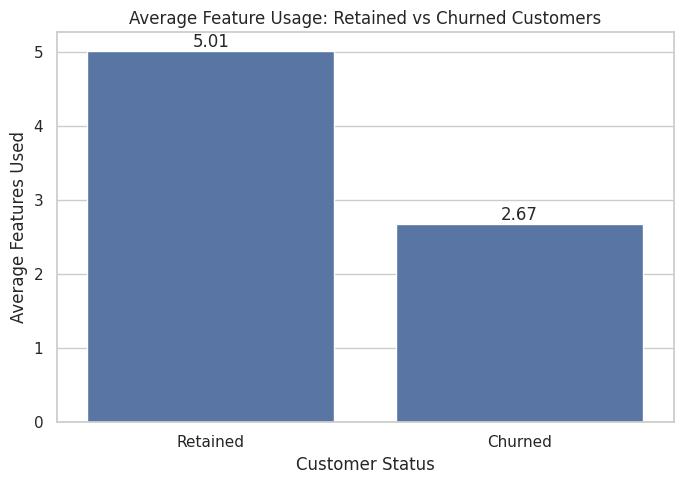

In [30]:
# Create a bar chart comparing average feature usage between
# retained and churned customers to identify differences in product adoption.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=feature_usage_df,
    x="Customer Status",
    y="Average Features Used"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Feature Usage: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Features Used")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers use an average of **5.01 platform features**.
- Churned customers use only **2.67 features** on average.
- Churned customers demonstrate approximately **47% lower feature adoption** compared with retained customers.
- Feature usage appears to be a strong behavioural indicator of customer retention.
- Encouraging customers to adopt more platform features could improve engagement and reduce churn risk.

## Business Insight

Product adoption shows a strong relationship with customer retention. Retained customers use an average of **5.01 features**, while churned customers use only **2.67 features**.

The lower feature adoption among churned customers suggests that customers who do not fully engage with the platform may perceive less value from the service and are more likely to cancel their subscriptions.

Increasing feature awareness through improved onboarding, training resources, and targeted product recommendations could help improve customer engagement and reduce churn.

### Conclusion

Feature adoption appears to be a significant factor influencing customer retention. Customers who engage with more platform capabilities are less likely to churn, suggesting that increasing product adoption should be a key focus of retention strategies.

The next analysis will examine whether customer inactivity, measured by days since last login, provides another strong indication of churn risk.

In [31]:
# Calculate the average number of days since last login for retained
# and churned customers to identify whether inactivity is linked to churn.

last_login_analysis = (
    customer_data
    .groupby("churn")["last_login_days_ago"]
    .mean()
    .round(2)
)

last_login_analysis

churn
0    29.39
1    64.80
Name: last_login_days_ago, dtype: float64

In [32]:
# Convert last login analysis into a structured table
# showing customer inactivity levels for retained and churned customers.

last_login_df = (
    last_login_analysis
    .reset_index()
)

last_login_df.columns = [
    "Customer Status",
    "Average Days Since Last Login"
]

last_login_df["Customer Status"] = (
    last_login_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

last_login_df

,Customer Status,Average Days Since Last Login
0,Retained,29.39
1,Churned,64.80


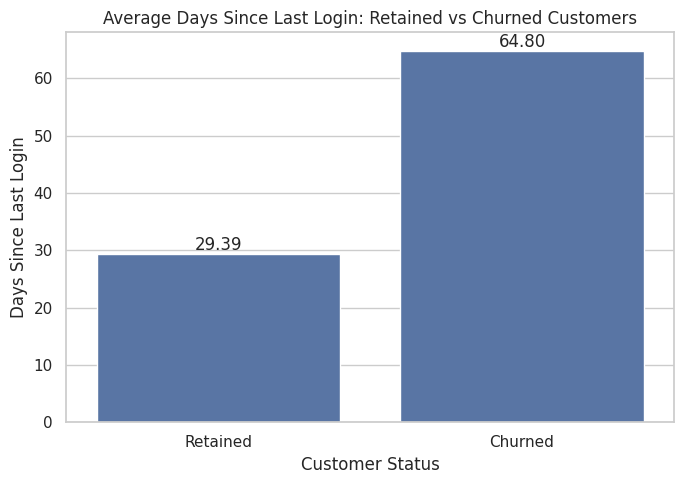

In [33]:
# Create a bar chart comparing average inactivity periods
# between retained and churned customers.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=last_login_df,
    x="Customer Status",
    y="Average Days Since Last Login"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Days Since Last Login: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Days Since Last Login")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers had an average inactivity period of **29.39 days**.
- Churned customers had an average inactivity period of **64.80 days**.
- Churned customers were inactive for approximately **35 additional days** compared with retained customers.
- Customer inactivity appears to be one of the strongest behavioural indicators of churn.
- Monitoring customer login activity could help identify high-risk customers before cancellation occurs.

## Business Insight

Customer inactivity shows a strong relationship with churn. Retained customers had logged into the platform approximately **29.39 days ago on average**, while churned customers had been inactive for approximately **64.80 days**.

Churned customers therefore experienced a significantly longer period of inactivity, suggesting that declining platform usage can act as an early warning indicator of customer churn risk.

The business can use login activity monitoring to identify disengaged customers and trigger proactive retention actions, such as customer success outreach, product training, or personalised engagement campaigns.

### Conclusion

Customer engagement metrics show clear differences between retained and churned customers. Lower login frequency, reduced feature adoption, and longer periods of inactivity are strongly associated with higher churn risk.

These findings suggest that customer engagement should be a key focus of retention strategies. The next analysis will investigate whether **customer support experience**, including complaints, response times, and satisfaction levels, also influences churn behaviour.

In [34]:
# Calculate the average number of complaints for retained and churned customers.
# This helps determine whether negative support experiences are associated with churn.

complaint_analysis = (
    customer_data
    .groupby("churn")["complaint_count"]
    .mean()
    .round(2)
)

complaint_analysis

churn
0    2.71
1    4.47
Name: complaint_count, dtype: float64

In [35]:
# Convert complaint analysis into a structured table
# showing average complaint levels for retained and churned customers.

complaint_analysis_df = (
    complaint_analysis
    .reset_index()
)

complaint_analysis_df.columns = [
    "Customer Status",
    "Average Complaint Count"
]

complaint_analysis_df["Customer Status"] = (
    complaint_analysis_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

complaint_analysis_df

,Customer Status,Average Complaint Count
0,Retained,2.71
1,Churned,4.47


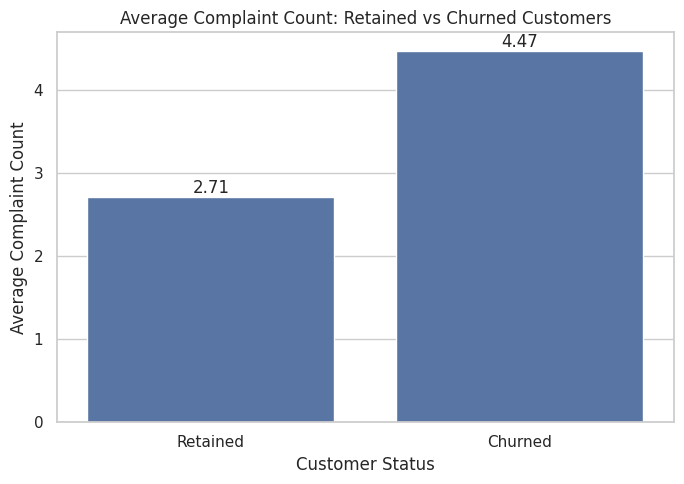

In [36]:
# Create a bar chart comparing average complaint counts
# between retained and churned customers.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=complaint_analysis_df,
    x="Customer Status",
    y="Average Complaint Count"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Complaint Count: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Complaint Count")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers reported an average of **2.71 complaints**.
- Churned customers reported an average of **4.47 complaints**.
- Churned customers generated approximately **65% more complaints** than retained customers.
- Higher complaint frequency appears to be associated with increased churn risk.
- Improving customer support quality and resolving issues effectively may help reduce customer attrition.

## Business Insight

Customer complaints show a clear relationship with churn. Retained customers submitted an average of **2.71 complaints**, while churned customers submitted **4.47 complaints**.

The higher complaint volume among churned customers suggests that repeated service issues or negative customer experiences may contribute to cancellation decisions.

Monitoring complaint activity can help the business identify dissatisfied customers earlier and provide proactive support interventions before they become lost customers.

### Conclusion

Complaint frequency appears to be an important indicator of customer dissatisfaction. Customers experiencing more issues are more likely to churn, highlighting the importance of proactive customer support and effective problem resolution.

The next analysis will investigate whether **support response time** influences customer retention outcomes.

In [37]:
# Calculate the average support response time for retained and churned customers.
# This evaluates whether slower support responses are associated with customer churn.

response_time_analysis = (
    customer_data
    .groupby("churn")["response_time_hours"]
    .mean()
    .round(2)
)

response_time_analysis

churn
0    18.65
1    20.73
Name: response_time_hours, dtype: float64

In [38]:
# Convert response time analysis into a structured table
# showing average support response time for retained and churned customers.

response_time_df = (
    response_time_analysis
    .reset_index()
)

response_time_df.columns = [
    "Customer Status",
    "Average Response Time (Hours)"
]

response_time_df["Customer Status"] = (
    response_time_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

response_time_df

,Customer Status,Average Response Time (Hours)
0,Retained,18.65
1,Churned,20.73


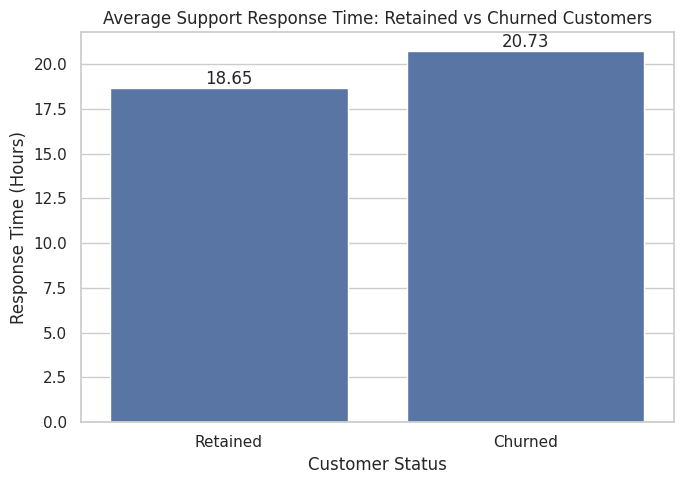

In [39]:
# Create a bar chart comparing average support response times
# between retained and churned customers.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=response_time_df,
    x="Customer Status",
    y="Average Response Time (Hours)"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Support Response Time: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Response Time (Hours)")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers experienced an average support response time of **18.65 hours**.
- Churned customers experienced an average support response time of **20.73 hours**.
- Churned customers waited approximately **2.08 additional hours** for support responses.
- Response time appears to have a weaker relationship with churn compared with engagement metrics such as login activity and feature usage.
- Improving response efficiency may contribute to better customer satisfaction and retention.

## Business Insight

Support response time shows a moderate relationship with customer churn. Retained customers experienced an average response time of **18.65 hours**, compared with **20.73 hours** for churned customers.

Although the difference is relatively small, slower support responses among churned customers suggest that delayed assistance may contribute to customer dissatisfaction when combined with other negative experiences such as frequent complaints or low satisfaction scores.

Support response time should therefore be monitored as part of a wider customer experience strategy rather than as a standalone churn predictor.

### Conclusion

Support response time shows some relationship with customer churn, but the impact appears smaller compared with behavioural engagement factors. This suggests that while efficient support is important, preventing churn requires a broader focus on customer engagement, product adoption, and overall satisfaction.

The next analysis will examine whether **resolution time** influences customer retention outcomes.

In [40]:
# Calculate the average support resolution time for retained and churned customers.
# This evaluates whether longer issue resolution periods are associated with churn.

resolution_time_analysis = (
    customer_data
    .groupby("churn")["resolution_time_hours"]
    .mean()
    .round(2)
)

resolution_time_analysis

churn
0    46.34
1    52.51
Name: resolution_time_hours, dtype: float64

In [41]:
# Convert resolution time analysis into a structured table
# showing average issue resolution time for retained and churned customers.

resolution_time_df = (
    resolution_time_analysis
    .reset_index()
)

resolution_time_df.columns = [
    "Customer Status",
    "Average Resolution Time (Hours)"
]

resolution_time_df["Customer Status"] = (
    resolution_time_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

resolution_time_df

,Customer Status,Average Resolution Time (Hours)
0,Retained,46.34
1,Churned,52.51


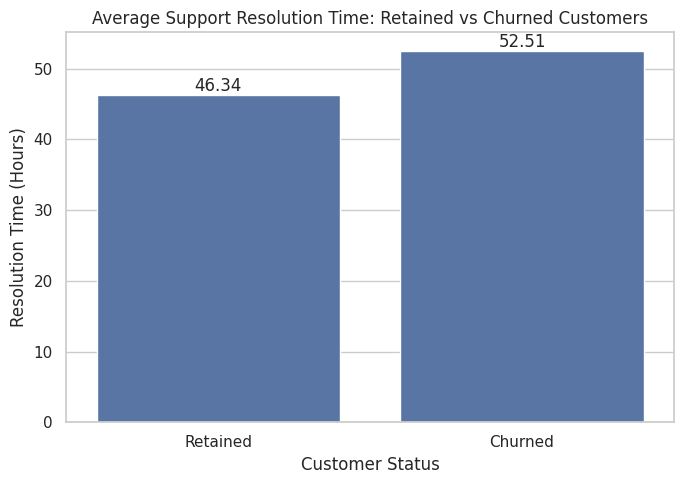

In [42]:
# Create a bar chart comparing average support resolution times
# between retained and churned customers.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=resolution_time_df,
    x="Customer Status",
    y="Average Resolution Time (Hours)"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Support Resolution Time: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Resolution Time (Hours)")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers had an average resolution time of **46.34 hours**.
- Churned customers had an average resolution time of **52.51 hours**.
- Churned customers experienced issues that took approximately **6.17 hours longer** to resolve.
- Longer resolution times appear to be associated with increased churn risk.
- Improving issue resolution processes may help reduce customer dissatisfaction and improve retention.

## Business Insight

Resolution time shows a relationship with customer churn. Retained customers experienced an average issue resolution time of **46.34 hours**, compared with **52.51 hours** for churned customers.

Customers who churned experienced support issues that took approximately **6 additional hours longer to resolve**, suggesting that delays in resolving customer problems may contribute to dissatisfaction and cancellation decisions.

Improving support efficiency and reducing resolution times could help improve customer experience and strengthen retention.

### Conclusion

Support resolution time appears to influence customer retention, with churned customers experiencing longer issue resolution periods. While the relationship is weaker than engagement factors such as login activity and feature adoption, efficient issue resolution remains an important part of maintaining customer satisfaction.

The final support analysis will examine whether **customer satisfaction scores** differ between retained and churned customers.

In [43]:
# Calculate the average customer satisfaction score for retained and churned customers.
# This evaluates whether customer satisfaction is linked to churn behaviour.

satisfaction_analysis = (
    customer_data
    .groupby("churn")["customer_satisfaction_score"]
    .mean()
    .round(2)
)

satisfaction_analysis

churn
0    6.71
1    5.56
Name: customer_satisfaction_score, dtype: float64

In [44]:
# Convert satisfaction analysis into a structured table
# showing average customer satisfaction levels for retained and churned customers.

satisfaction_df = (
    satisfaction_analysis
    .reset_index()
)

satisfaction_df.columns = [
    "Customer Status",
    "Average Satisfaction Score"
]

satisfaction_df["Customer Status"] = (
    satisfaction_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

satisfaction_df

,Customer Status,Average Satisfaction Score
0,Retained,6.71
1,Churned,5.56


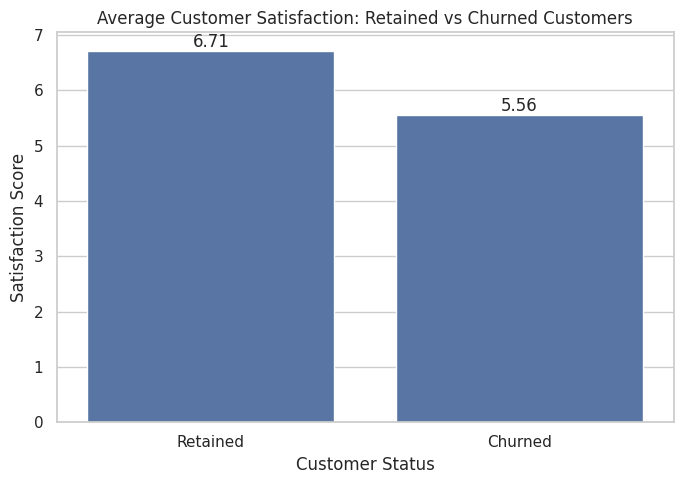

In [45]:
# Create a bar chart comparing average satisfaction scores
# between retained and churned customers.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=satisfaction_df,
    x="Customer Status",
    y="Average Satisfaction Score"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Customer Satisfaction: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Satisfaction Score")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers reported an average satisfaction score of **6.71**.
- Churned customers reported an average satisfaction score of **5.56**.
- Churned customers had satisfaction scores approximately **17% lower** than retained customers.
- Lower customer satisfaction appears to be associated with increased churn risk.
- Improving customer experience should be a key focus area for retention strategies.

## Business Insight

Customer satisfaction shows a clear relationship with churn. Retained customers reported an average satisfaction score of **6.71**, compared with **5.56** among churned customers.

The lower satisfaction levels among churned customers suggest that negative customer experiences, unresolved issues, and reduced perceived value may contribute to cancellation decisions.

Improving customer satisfaction through better support experiences, faster issue resolution, and proactive customer engagement could help reduce churn and improve long-term retention.

### Conclusion

Customer satisfaction is an important factor influencing customer retention. Churned customers consistently show lower satisfaction levels, combined with higher complaint volumes and longer support resolution times.

The support analysis suggests that improving customer experience through faster resolution, proactive communication, and better issue management could reduce customer churn.

# 7.4 Average Session Time vs Churn

## Business Question

Does the amount of time customers spend on the platform differ between retained and churned customers?

Understanding whether session depth is associated with churn can help determine whether customers who spend less time using the product are more likely to leave.

In [46]:
# Calculate the average session duration for retained and churned customers.
# This helps identify whether engagement depth differs between customer groups.

session_analysis = (
    customer_data
    .groupby("churn")["average_session_time_minutes"]
    .mean()
    .round(2)
)

session_analysis

churn
0    25.10
1    24.96
Name: average_session_time_minutes, dtype: float64

In [47]:
# Convert session analysis into a structured table
# showing average session duration for retained and churned customers.

session_analysis_df = (
    session_analysis
    .reset_index()
)

session_analysis_df.columns = [
    "Customer Status",
    "Average Session Time (Minutes)"
]

session_analysis_df["Customer Status"] = (
    session_analysis_df["Customer Status"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

session_analysis_df

,Customer Status,Average Session Time (Minutes)
0,Retained,25.10
1,Churned,24.96


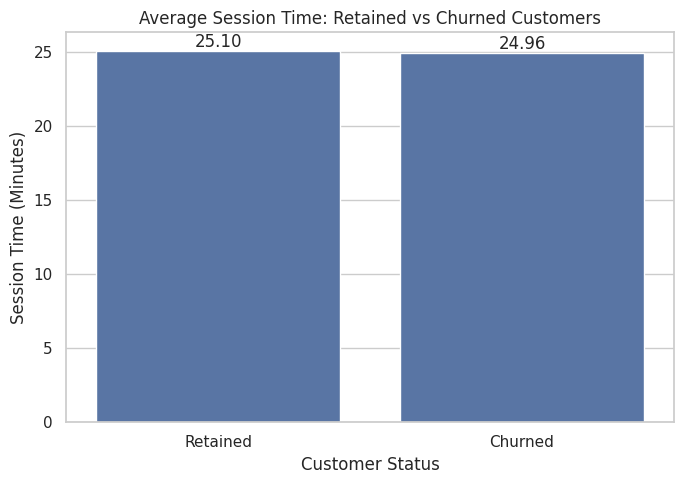

In [48]:
# Create a bar chart comparing average session duration
# between retained and churned customers.

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=session_analysis_df,
    x="Customer Status",
    y="Average Session Time (Minutes)"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Session Time: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Session Time (Minutes)")

plt.tight_layout()

plt.show()

## Key Findings

- Retained customers had an average session duration of **25.10 minutes**.
- Churned customers had an average session duration of **24.96 minutes**.
- The difference between the two groups was minimal.
- Session duration appears to be a weaker churn indicator compared with login frequency, feature usage, and inactivity.
- Customer engagement quality and consistency may be more important than individual session length.

## Business Insight

Average session duration shows little difference between retained and churned customers. Retained customers spent approximately **25.10 minutes per session**, while churned customers spent **24.96 minutes**.

This suggests that session length alone is not a strong indicator of churn risk. Although customers may spend a similar amount of time on the platform during individual sessions, factors such as login frequency, feature adoption, and inactivity appear to have a stronger relationship with customer retention.

### Conclusion

Session duration alone does not appear to significantly influence customer churn. While customers spend a similar amount of time during each session, churn is more strongly associated with overall engagement patterns, including login frequency, feature adoption, and periods of inactivity.

The customer engagement analysis is now complete and highlights the key behavioural factors linked with churn risk.

# EDA Final Summary & Business Recommendations

## Overview

The exploratory data analysis investigated customer churn patterns within the InsightFlow Analytics SaaS customer base. The objective was to identify customer characteristics, behaviours, and experiences associated with customer retention and churn.

The analysis examined customer demographics, subscription information, revenue impact, engagement behaviour, and support experience.

---

# Key Findings

## 1. Customer Churn Overview

The dataset contains 10,000 customers, with:

- 85.39% retained customers
- 14.61% churned customers

The churn rate represents a significant business challenge because customer cancellations directly impact recurring revenue.

---

## 2. Revenue Impact

Customer churn has a measurable financial impact:

- Total monthly recurring revenue: £733,000
- Revenue lost from churned customers: £110,416
- Percentage of revenue lost: 15.06%

Reducing churn represents an opportunity to protect recurring revenue and improve customer lifetime value.

---

## 3. Customer Engagement Insights

Customer engagement was identified as one of the strongest indicators of churn.

Churned customers:

- Logged in significantly less frequently
- Used fewer platform features
- Had longer periods since their last login

Key findings:

- Retained customers averaged 14.98 monthly logins compared with 6.40 for churned customers.
- Retained customers used 5.01 features compared with 2.67 for churned customers.
- Churned customers had been inactive for approximately 64.80 days compared with 29.39 days for retained customers.

These results suggest declining engagement is an important early warning signal for churn risk.

---

## 4. Customer Support Experience

Support experience also showed relationships with customer churn.

Churned customers:

- Submitted more complaints
- Experienced longer resolution times
- Reported lower satisfaction scores

Key findings:

- Average complaints:
    - Retained customers: 2.71
    - Churned customers: 4.47

- Average resolution time:
    - Retained customers: 46.34 hours
    - Churned customers: 52.51 hours

- Average satisfaction score:
    - Retained customers: 6.71
    - Churned customers: 5.56

These findings suggest improving customer support processes may help reduce churn.

---

## 5. Weaker Churn Indicators

Some variables showed limited differences between retained and churned customers.

Examples:

### Subscription Type

Churn rates were similar across subscription plans, suggesting subscription level alone is not a strong churn predictor.

### Region

Regional churn differences were relatively small.

### Session Duration

Average session time was almost identical:

- Retained customers: 25.10 minutes
- Churned customers: 24.96 minutes

This suggests engagement consistency is more important than individual session length.

---

# Overall Business Conclusion

The exploratory analysis indicates that customer churn is mainly associated with behavioural engagement and customer experience factors.

The strongest churn indicators identified are:

1. Reduced login frequency
2. Lower feature adoption
3. Increased customer inactivity
4. Higher complaint volume
5. Lower customer satisfaction

These findings suggest that retention strategies should focus on improving customer engagement, encouraging product adoption, and proactively supporting customers showing signs of disengagement.

---

# Recommendations

Based on the analysis, InsightFlow Analytics should consider:

## 1. Develop Early Warning Alerts

Monitor:

- Login inactivity
- Declining feature usage
- Increased complaints

Customers showing these behaviours should receive proactive engagement.

---

## 2. Improve Customer Onboarding

Encourage new customers to:

- Explore more platform features
- Complete product training
- Understand the value of available tools

Higher product adoption may improve retention.

---

## 3. Strengthen Customer Support

Actions:

- Reduce resolution times
- Prioritise customers with repeated complaints
- Improve customer communication during issue resolution

---

## 4. Build a Churn Prediction Model

The identified churn indicators can be used as features in a machine learning model to predict customers at risk of leaving.

The next phase will use statistical analysis and predictive modelling to validate and predict customer churn behaviour.